Sample code for applying model weights to the USGS NCCV hydrology files found at: https://www.sciencebase.gov/catalog/item/651c8100d34e44db0e2ce2d9

This code requires the NCCV2_LOCA2_model_extended_meta.csv file to load either LOCA2-specific model weights or the weights found in the NCA5 assessment.

In [18]:
import os
import matplotlib
import pandas as pd
import xarray as xr
from itertools import product
from dask.distributed import Client
import platform
from glob import glob
import rioxarray

ModuleNotFoundError: No module named 'rioxarray'

Due to the size of the data, we will use Dask to calculate the weighted multimodel mean.

In [2]:
hostname = platform.uname()[1]
client = Client()
print(f"Dask Dashboard is available at: {client.dashboard_link.replace("127.0.0.1", hostname)}")

Dask Dashboard is available at: http://SpudsCouch:8787/status


Define your paths and which variables you'd like to include. Keep in mind, xarray uses lazy loading, so variables you don't use won't be loaded anyway.

In [4]:
data_path = 'F:/Wetland_Climate_Impacts/Climate_Data/USGS_Water_Balance'
meta_data_file = 'F:/Wetland_Climate_Impacts/Climate_Data/USGS_Water_Balance/NCCV2_LOCA2_model_extended_meta.csv'
variables = ['aet','deficit','pet','runoff','snow','stor']
weight_type = 'NCA5_BMA_weight' # or 'LOCA2_BMA_weight'

When using the LOCA2-specific weights, the number of models vary based on SSP (ssp245=24, ssp370=23, ssp585=25 models). Since the number of models vary, the weighted ensemble mean will be slightly different because of the inclusion or exclusion of one or two models. For the sake of the example, I am only processing one SSP at a time.

If you want to use the NCA5_BMA_weight, there are 16 GCMs regardless of SSP, so you could use a single weighted historical for all SSP245, 370, and 585. You could do the same with the LOCA2-specific weights if you manually made sure only to use the common models, forcing n=23 for all scenarios.

Just be careful you aren't mixing different ensemble means that were made with a different balance of weights.

In [5]:
scenario = 'ssp585'

Load the metadata file, filter only for our selected SSP, and create a unqiue ensemble ID (model.scenario.ripf).

In [6]:
df = pd.read_csv(meta_data_file, encoding="ISO-8859-1")
df = df[df['EXP'] == scenario]
df['ensemble'] = df['MODEL']+"."+df['EXP']+"."+df['RIPF']
df

,MODEL,RIPF,EXP,ECS_filter (very likely),ECS_filter (likely),NCA5_BMA_weight,GWL_1.5_start_year,GWL_1.5_end_year,GWL_2.0_start_year,GWL_2.0_end_year,GWL_3.0_start_year,GWL_3.0_end_year,country_code,model_center,LOCA2_BMA_weight,ensemble
2,ACCESS-CM2,r1i1p1f1,ssp585,1,0,0.0412,2016,2035,2029,2048,2046,2065,AU,CSIRO-ARCCSS CSIRO and Austr. Res. Council Cen...,0.0182,ACCESS-CM2.ssp585.r1i1p1f1
5,ACCESS-ESM1-5,r1i1p1f1,ssp585,1,1,0.0581,2018,2037,2030,2049,2051,2070,AU,CSIRO Commonwealth Scientific and Industrial R...,0.0317,ACCESS-ESM1-5.ssp585.r1i1p1f1
8,AWI-CM-1-1-MR,r1i1p1f1,ssp585,1,1,0.0000,2010,2029,2027,2046,2050,2069,DE,AWI Alfred Wegener Institute Germany,0.0526,AWI-CM-1-1-MR.ssp585.r1i1p1f1
11,BCC-CSM2-MR,r1i1p1f1,ssp585,1,1,0.0723,2021,2040,2034,2053,2056,2075,CN,"BCC Beijing Climate Centre, China",0.0569,BCC-CSM2-MR.ssp585.r1i1p1f1
13,CNRM-CM6-1-HR,r1i1p1f2,ssp585,1,0,0.0000,2009,2028,2020,2039,2042,2061,FR,CNRM Centre National de Recherches Mtorologi...,0.0217,CNRM-CM6-1-HR.ssp585.r1i1p1f2
16,CNRM-CM6-1,r1i1p1f2,ssp585,1,0,0.0000,2019,2038,2031,2050,2049,2068,FR,CNRM Centre National de Recherches Mtorologi...,0.0159,CNRM-CM6-1.ssp585.r1i1p1f2
19,CNRM-ESM2-1,r1i1p1f2,ssp585,1,0,0.0000,2023,2042,2036,2055,2055,2074,FR,CNRM Centre National de Recherches Mtorologi...,0.0167,CNRM-ESM2-1.ssp585.r1i1p1f2
22,CanESM5,r1i1p1f1,ssp585,0,0,0.0290,2003,2022,2013,2032,2031,2050,CA,CCCMa Canadian Centre for Climate Modelling an...,0.0112,CanESM5.ssp585.r1i1p1f1
25,EC-Earth3-Veg,r1i1p1f1,ssp585,1,0,0.0000,2002,2021,2018,2037,2041,2060,EU,EC-Earth Consortium Europe,0.0225,EC-Earth3-Veg.ssp585.r1i1p1f1
28,EC-Earth3,r1i1p1f1,ssp585,0,0,0.0498,2015,2034,2026,2045,2048,2067,EU,EC-Earth Consortium Europe,0.0248,EC-Earth3.ssp585.r1i1p1f1


Drop most of the DataFrame and only keep the weights we want and the ensemble ID (also making it an index)

In [7]:
df_weight = df.set_index('ensemble')[weight_type]
df_weight

ensemble
ACCESS-CM2.ssp585.r1i1p1f1         0.0412
ACCESS-ESM1-5.ssp585.r1i1p1f1      0.0581
AWI-CM-1-1-MR.ssp585.r1i1p1f1      0.0000
BCC-CSM2-MR.ssp585.r1i1p1f1        0.0723
CNRM-CM6-1-HR.ssp585.r1i1p1f2      0.0000
CNRM-CM6-1.ssp585.r1i1p1f2         0.0000
CNRM-ESM2-1.ssp585.r1i1p1f2        0.0000
CanESM5.ssp585.r1i1p1f1            0.0290
EC-Earth3-Veg.ssp585.r1i1p1f1      0.0000
EC-Earth3.ssp585.r1i1p1f1          0.0498
FGOALS-g3.ssp585.r1i1p1f1          0.0716
GFDL-CM4.ssp585.r1i1p1f1           0.0000
GFDL-ESM4.ssp585.r1i1p1f1          0.0589
HadGEM3-GC31-LL.ssp585.r1i1p1f3    0.0000
HadGEM3-GC31-MM.ssp585.r1i1p1f3    0.0000
INM-CM4-8.ssp585.r1i1p1f1          0.0646
INM-CM5-0.ssp585.r1i1p1f1          0.0649
IPSL-CM6A-LR.ssp585.r1i1p1f1       0.0449
KACE-1-0-G.ssp585.r1i1p1f1         0.0000
MIROC6.ssp585.r1i1p1f1             0.0767
MPI-ESM1-2-HR.ssp585.r1i1p1f1      0.0731
MPI-ESM1-2-LR.ssp585.r1i1p1f1      0.0755
MRI-ESM2-0.ssp585.r1i1p1f1         0.0730
NorESM2-LM.ssp585.r1i1p1f

Since the ensemble ID is an index, we can easily convert this Pandas DataFrame to a xarray DataArray.

In [8]:
weight_da = df_weight.to_xarray()
weight_da

<xarray.DataArray 'NCA5_BMA_weight' (ensemble: 25)> Size: 200B
array([0.0412, 0.0581, 0.    , 0.0723, 0.    , 0.    , 0.    , 0.029 ,
       0.    , 0.0498, 0.0716, 0.    , 0.0589, 0.    , 0.    , 0.0646,
       0.0649, 0.0449, 0.    , 0.0767, 0.0731, 0.0755, 0.073 , 0.0736,
       0.0727])
Coordinates:
  * ensemble  (ensemble) object 200B 'ACCESS-CM2.ssp585.r1i1p1f1' ... 'NorESM...

Use clever Python expansion to build our list of files

In [9]:
hist_files = [
    f'{data_path}/{var}/historical/{var}_MWBM_LOCA2.{ensemble_id.replace(scenario, 'historical')}_1950-2014.nc'
    for ensemble_id,var in product(list(weight_da.ensemble.values), variables)
]
#hist_files
#for f in hist_files:
#    try:
#        xr.open_dataset(f)
#        print(f"Successfully opened {f}")
#    except Exception as e:
#        print(f"Error with {f}: {e}")

In [10]:
ssp_files = [
    f'{data_path}/{var}/{scenario}/{var}_MWBM_LOCA2.{ensemble_id}_2015-2100.nc'
    for ensemble_id,var in product(list(weight_da.ensemble.values), variables)
]
#ssp_files

Using xarray's open_mfdataset function, we can easily open and combine all the files at once. However, they need something to align on, so we use a preprocessor function (read the docs) to find the CMIP metadata in each file and construct a ensemble ID (as we did the the metadata DataFrame). We use this ensemble ID to create a new 4th dimension for each model. This allows us to load all models at once.

Some of the variables were loading as float64, which takes more memory and is not needed, so I cast them all to float32 datatype.

In [11]:
def get_ensemble_id_from_netcdf_metadata(ds):
    ensemble = f"{ds.attrs['model']}.{ds.attrs['experiment']}.{ds.attrs['ripf']}"
    return ds.expand_dims('ensemble').assign_coords(ensemble=[ensemble]).astype('float32')

Using the preprocessor, we can now load and combine all historical files.

In [14]:
ds_hist = xr.open_mfdataset(hist_files, 
                            chunks={}, 
                            preprocess=get_ensemble_id_from_netcdf_metadata, 
                            combine_attrs="drop_conflicts")
ds_hist

<xarray.Dataset> Size: 209GB
Dimensions:   (ensemble: 25, time: 780, lat: 474, lon: 944)
Coordinates:
  * time      (time) datetime64[ns] 6kB 1950-01-15T00:00:00.000040233 ... 201...
  * lat       (lat) float64 4kB 23.91 23.97 24.03 24.09 ... 53.34 53.41 53.47
  * lon       (lon) float64 8kB -125.5 -125.4 -125.3 ... -66.66 -66.59 -66.53
  * ensemble  (ensemble) <U35 4kB 'ACCESS-CM2.historical.r1i1p1f1' ... 'NorES...
Data variables:
    aet       (ensemble, time, lat, lon) float32 35GB dask.array<chunksize=(1, 360, 158, 236), meta=np.ndarray>
    deficit   (ensemble, time, lat, lon) float32 35GB dask.array<chunksize=(1, 360, 158, 236), meta=np.ndarray>
    pet       (ensemble, time, lat, lon) float32 35GB dask.array<chunksize=(1, 360, 158, 236), meta=np.ndarray>
    runoff    (ensemble, time, lat, lon) float32 35GB dask.array<chunksize=(1, 360, 158, 236), meta=np.ndarray>
    snow      (ensemble, time, lat, lon) float32 35GB dask.array<chunksize=(1, 360, 158, 236), meta=np.ndarray>
    stor      (ensemble, time, lat, lon) float32 35GB dask.array<chunksize=(1, 360, 158, 236), meta=np.ndarray>
Attributes:
    title:                Monthly Water Balance Model output driven by CMIP6-...
    institution:          U.S. Geological Survey, Corvallis, OR
    source:               IDL implementation of MWBM
    references:           Hostetler, S. W., & Alder, J. R. (2016). Implementa...
    contact:              Jay Alder (jalder@usgs.gov)
    Conventions:          CF-1.6
    disclaimer:           Although these data have been processed successfull...
    citation:             Alder, J.R., 2023, CMIP6 LOCA2 Monthly Water Balanc...
    source_climate_data:  LOCA2 (Pierce, D. W., Cayan, D. R., Feldman, D. R.,...
    experiment:           historical

We do the same for the selected SSP files

In [16]:
ds_ssp = xr.open_mfdataset(ssp_files, 
                           chunks={}, 
                           preprocess=get_ensemble_id_from_netcdf_metadata, 
                           combine_attrs="drop_conflicts")
ds_ssp

<xarray.Dataset> Size: 277GB
Dimensions:   (ensemble: 25, time: 1032, lat: 474, lon: 944)
Coordinates:
  * time      (time) datetime64[ns] 8kB 2015-01-15T00:00:00.000040192 ... 210...
  * lat       (lat) float64 4kB 23.91 23.97 24.03 24.09 ... 53.34 53.41 53.47
  * lon       (lon) float64 8kB -125.5 -125.4 -125.3 ... -66.66 -66.59 -66.53
  * ensemble  (ensemble) <U31 3kB 'ACCESS-CM2.ssp585.r1i1p1f1' ... 'NorESM2-M...
Data variables:
    aet       (ensemble, time, lat, lon) float32 46GB dask.array<chunksize=(1, 360, 158, 236), meta=np.ndarray>
    deficit   (ensemble, time, lat, lon) float32 46GB dask.array<chunksize=(1, 360, 158, 236), meta=np.ndarray>
    pet       (ensemble, time, lat, lon) float32 46GB dask.array<chunksize=(1, 360, 158, 236), meta=np.ndarray>
    runoff    (ensemble, time, lat, lon) float32 46GB dask.array<chunksize=(1, 360, 158, 236), meta=np.ndarray>
    snow      (ensemble, time, lat, lon) float32 46GB dask.array<chunksize=(1, 360, 158, 236), meta=np.ndarray>
    stor      (ensemble, time, lat, lon) float32 46GB dask.array<chunksize=(1, 360, 158, 236), meta=np.ndarray>
Attributes:
    title:                Monthly Water Balance Model output driven by CMIP6-...
    institution:          U.S. Geological Survey, Corvallis, OR
    source:               IDL implementation of MWBM
    references:           Hostetler, S. W., & Alder, J. R. (2016). Implementa...
    contact:              Jay Alder (jalder@usgs.gov)
    Conventions:          CF-1.6
    disclaimer:           Although these data have been processed successfull...
    citation:             Alder, J.R., 2023, CMIP6 LOCA2 Monthly Water Balanc...
    source_climate_data:  LOCA2 (Pierce, D. W., Cayan, D. R., Feldman, D. R.,...
    experiment:           ssp585

Rename the historical ensemble ID from model.historical.ripf to model.ssp.ripf so they can be concatenated. We need the ensemble ID labels to match between historical and SSP, so we force them to use the SSP IDs.

In [17]:
ds_hist['ensemble'] = ds_hist.ensemble.str.replace('historical', scenario)
ds_hist

<xarray.Dataset> Size: 209GB
Dimensions:   (ensemble: 25, time: 780, lat: 474, lon: 944)
Coordinates:
  * time      (time) datetime64[ns] 6kB 1950-01-15T00:00:00.000040233 ... 201...
  * lat       (lat) float64 4kB 23.91 23.97 24.03 24.09 ... 53.34 53.41 53.47
  * lon       (lon) float64 8kB -125.5 -125.4 -125.3 ... -66.66 -66.59 -66.53
  * ensemble  (ensemble) <U31 3kB 'ACCESS-CM2.ssp585.r1i1p1f1' ... 'NorESM2-M...
Data variables:
    aet       (ensemble, time, lat, lon) float32 35GB dask.array<chunksize=(1, 360, 158, 236), meta=np.ndarray>
    deficit   (ensemble, time, lat, lon) float32 35GB dask.array<chunksize=(1, 360, 158, 236), meta=np.ndarray>
    pet       (ensemble, time, lat, lon) float32 35GB dask.array<chunksize=(1, 360, 158, 236), meta=np.ndarray>
    runoff    (ensemble, time, lat, lon) float32 35GB dask.array<chunksize=(1, 360, 158, 236), meta=np.ndarray>
    snow      (ensemble, time, lat, lon) float32 35GB dask.array<chunksize=(1, 360, 158, 236), meta=np.ndarray>
    stor      (ensemble, time, lat, lon) float32 35GB dask.array<chunksize=(1, 360, 158, 236), meta=np.ndarray>
Attributes:
    title:                Monthly Water Balance Model output driven by CMIP6-...
    institution:          U.S. Geological Survey, Corvallis, OR
    source:               IDL implementation of MWBM
    references:           Hostetler, S. W., & Alder, J. R. (2016). Implementa...
    contact:              Jay Alder (jalder@usgs.gov)
    Conventions:          CF-1.6
    disclaimer:           Although these data have been processed successfull...
    citation:             Alder, J.R., 2023, CMIP6 LOCA2 Monthly Water Balanc...
    source_climate_data:  LOCA2 (Pierce, D. W., Cayan, D. R., Feldman, D. R.,...
    experiment:           historical

Combine historical + ssp for one single time series, for all models, all variables. Add weights to dataset as well. Notice the weights xr.DataArray aligns -by ID- across the xr.DataSet. This makes sure we don't jumble up the order of the model data vs the model weights.

At this point the xr.Dataset will be rather large (75 Gb per variable). Dask will load chunks of data on the fly as it needs them. However, if your computer is running out of memory or struggling, you can reduce the chunk size (read the xarray docs). The defualt with these data are ~50 Mb / chunk, which is pretty reasonable.

In [13]:
ds = xr.concat([ds_hist, ds_ssp], dim="time")
ds['weights'] = weight_da

# ---- rechunk as needed here; it is currently [1, 360, 158, 236] ~ 50 Mb/chunk. 
# ---- You could go higher or lower depending on the performance or amount of memory you have.

ds

NameError: name 'ds_ssp' is not defined

We can now create a weighted xr.Dataset for each year in the dataset. The weights var can be dropped because it is no longer needed.

In [17]:
weighted_ensemble_ds = ds.weighted(ds.weights).mean(dim="ensemble", keep_attrs=True).drop_vars("weights")
weighted_ensemble_ds

<xarray.Dataset> Size: 39GB
Dimensions:  (time: 1812, lat: 474, lon: 944)
Coordinates:
  * time     (time) datetime64[ns] 14kB 1950-01-15T00:00:00.000040233 ... 210...
  * lat      (lat) float64 4kB 23.91 23.97 24.03 24.09 ... 53.34 53.41 53.47
  * lon      (lon) float64 8kB -125.5 -125.4 -125.3 ... -66.66 -66.59 -66.53
Data variables:
    aet      (time, lat, lon) float64 6GB dask.array<chunksize=(360, 158, 236), meta=np.ndarray>
    deficit  (time, lat, lon) float64 6GB dask.array<chunksize=(360, 158, 236), meta=np.ndarray>
    pet      (time, lat, lon) float64 6GB dask.array<chunksize=(360, 158, 236), meta=np.ndarray>
    runoff   (time, lat, lon) float64 6GB dask.array<chunksize=(360, 158, 236), meta=np.ndarray>
    snow     (time, lat, lon) float64 6GB dask.array<chunksize=(360, 158, 236), meta=np.ndarray>
    stor     (time, lat, lon) float64 6GB dask.array<chunksize=(360, 158, 236), meta=np.ndarray>
Attributes:
    title:                Monthly Water Balance Model output driven by CMIP6-...
    institution:          U.S. Geological Survey, Corvallis, OR
    source:               IDL implementation of MWBM
    references:           Hostetler, S. W., & Alder, J. R. (2016). Implementa...
    contact:              Jay Alder (jalder@usgs.gov)
    Conventions:          CF-1.6
    disclaimer:           Although these data have been processed successfull...
    citation:             Alder, J.R., 2023, CMIP6 LOCA2 Monthly Water Balanc...
    source_climate_data:  LOCA2 (Pierce, D. W., Cayan, D. R., Feldman, D. R.,...
    experiment:           historical

However, we need to be a little careful since the order of operation often matters. For example, if you want to create the weighted ensemble climatology, it is likely best to calculate the climatology first for each model, then apply the multimodel weights.

In [1]:
ds_clim_2041_2070 = ds.sel(time=slice("2041-01-01","2070-12-31")).mean(dim="time")


NameError: name 'ds' is not defined

In [19]:
weighted_ds_clim = ds_clim.weighted(ds_clim.weights).mean(dim="ensemble", keep_attrs=True).drop_vars("weights")
weighted_ds_clim

<xarray.Dataset> Size: 21MB
Dimensions:  (lat: 474, lon: 944)
Coordinates:
  * lat      (lat) float64 4kB 23.91 23.97 24.03 24.09 ... 53.34 53.41 53.47
  * lon      (lon) float64 8kB -125.5 -125.4 -125.3 ... -66.66 -66.59 -66.53
Data variables:
    aet      (lat, lon) float64 4MB dask.array<chunksize=(158, 236), meta=np.ndarray>
    deficit  (lat, lon) float64 4MB dask.array<chunksize=(158, 236), meta=np.ndarray>
    pet      (lat, lon) float64 4MB dask.array<chunksize=(158, 236), meta=np.ndarray>
    runoff   (lat, lon) float64 4MB dask.array<chunksize=(158, 236), meta=np.ndarray>
    snow     (lat, lon) float64 4MB dask.array<chunksize=(158, 236), meta=np.ndarray>
    stor     (lat, lon) float64 4MB dask.array<chunksize=(158, 236), meta=np.ndarray>

In [ ]:
Let's plot snow just as an example. This is the point where xarray and Dask will start loading and processing data. This step can take a couple minutes. If you have the Dask dashboard open in your browser, you should now see a lot of activity as it loads and processes the data.

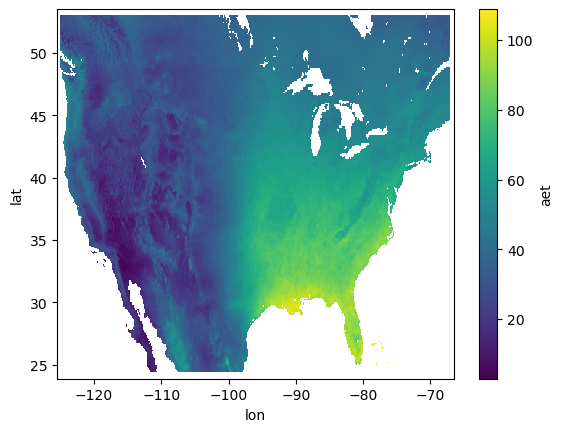

In [23]:
weighted_ds_clim.aet.plot()

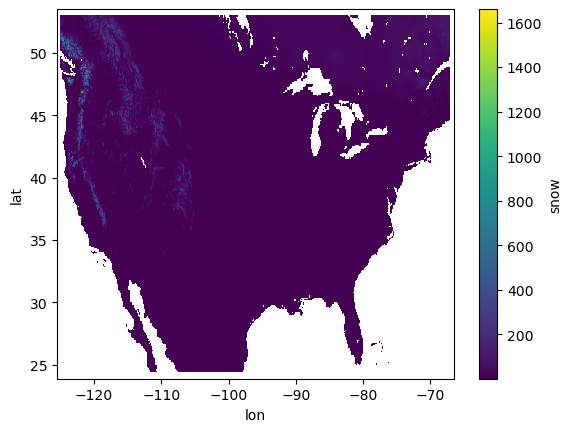

In [24]:
weighted_ds_clim.snow.plot()

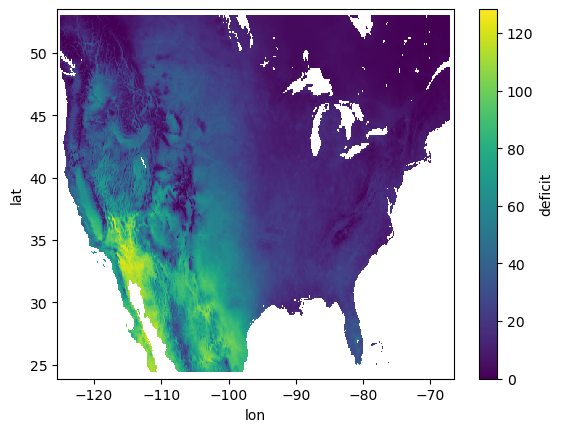

In [25]:
weighted_ds_clim.deficit.plot()

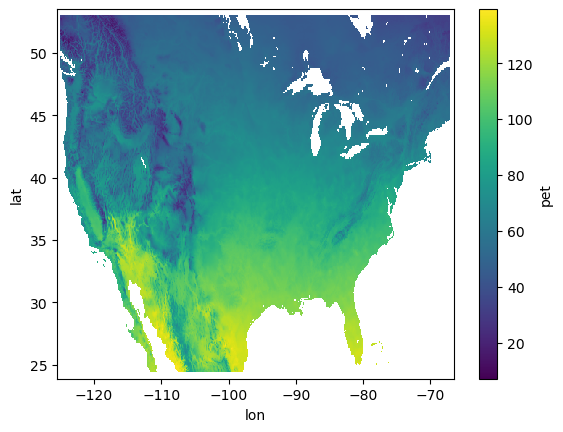

In [26]:
weighted_ds_clim.pet.plot()

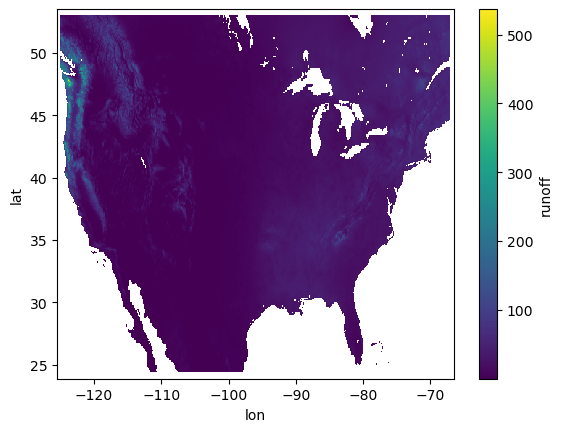

In [27]:
weighted_ds_clim.runoff.plot()

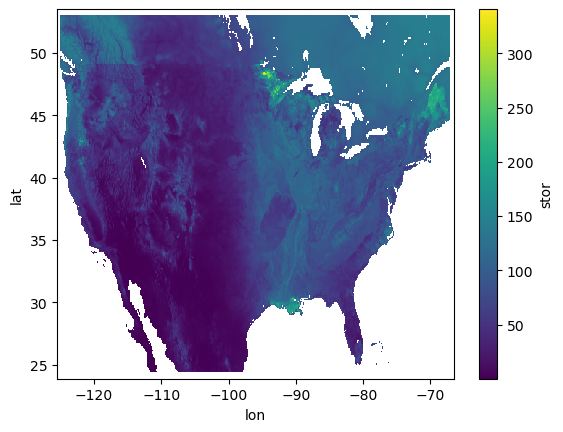

In [28]:
weighted_ds_clim.stor.plot()

You are pretty much done at this point. You could save variables out to a new NetCDF or just do plotting. As I showed above, I would favor doing whatever averaging or summary you need to do first, and then apply the ensemble multimodel weights as the last step.

You are probably fine to spatially average grids -> HUCs using the weighted ensemble, but I would do temporal averaging before the model weighting just in case the order of operation matters.

Close the Dask dashboard.

In [118]:
client.close()